# Numerically solving the Schrodinger equation

In this assignment you will use [<tt>qmsolve</tt>](https://github.com/quantum-visualizations/qmsolve) to solve the time-independent Schrodinger equation in one dimension and plot the solutions.

### First, install <tt>qmsolve</tt> in one of two ways:
<ul>
    <li>From a <tt>unix</tt> command line, type <tt>pip install qmsolve</tt></li>
    <li>Put the following commands in a code cell in this notebook and execute:<br />
        <tt>import sys</tt><br />
        <tt>!{sys.executable} -m pip install qmsolve</tt></li>
</ul>

### Homework problems:

<ol start=0>
    <li>Follow the link to the <tt>qmsolve</tt> GitHub page above. Click the link for the <tt>examples</tt> folder, then click on the <tt>eigenstate solver examples</tt> folder. Finally, click on <tt>1D_harmonic_oscillator.py</tt> to see a short code snippet that will calculate wavefunctions for a simple harmonic oscillator (SHO).</li>
    <li><tt>1D_harmonic_oscillator.py</tt> imports the <tt>Hamiltonian</tt> class from <tt>qmsolve</tt>. In quantum mechanics, what is a Hamiltonian? Please use multiple sources to formulate your answer and cite those sources. For this problem, crowd-sourced references such as Wikipedia and stackexchange are acceptable.</li>
    <li>Which force law is defined in the function <tt>harmonic_oscillator()</tt> in cell 2 of this notebook?</li>
    <li>What are the eigenstates referred to in lines 22 and 23 in <tt>1D_harmonic_oscillator.py</tt>? Again, please use multiple sources to formulate your answer and cite those sources.
    <li>Code cells 1 and 2 below contain imported code from <tt>1D_harmonic_oscillator.py</tt>, including a visualization of eigenstate 0 of the SHO. In subsequent code cells, plot any five SHO eigenstates of your choice.</li>
</ol>

Note: you can write your answers to the non-code problems in a markdown cell. From within a new notebook cell, click the box with the downward-pointing arrow that says "Code" (on your Jupyter toolbar) and change to "Markdown". Then you can just type in the cell like a regular text file.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from qmsolve import Hamiltonian, SingleParticle, init_visualization, Å, eV

Computing...
Took 0.010922670364379883
[ 13.8243627   41.46350403  69.08346722  96.68423227 124.26577906
 151.82808744 179.37113718 206.89490796 234.39937942 261.8845311
 289.35034249 316.79679298 344.22386192 371.63152856 399.01977209
 426.38857162 453.73790619 481.06775475 508.3780962  535.66890934
 562.9401729  590.19186555 617.42396585 644.63645231 671.82930335
 699.00249732 726.15601246 753.28982697 780.40391895 807.49826642]


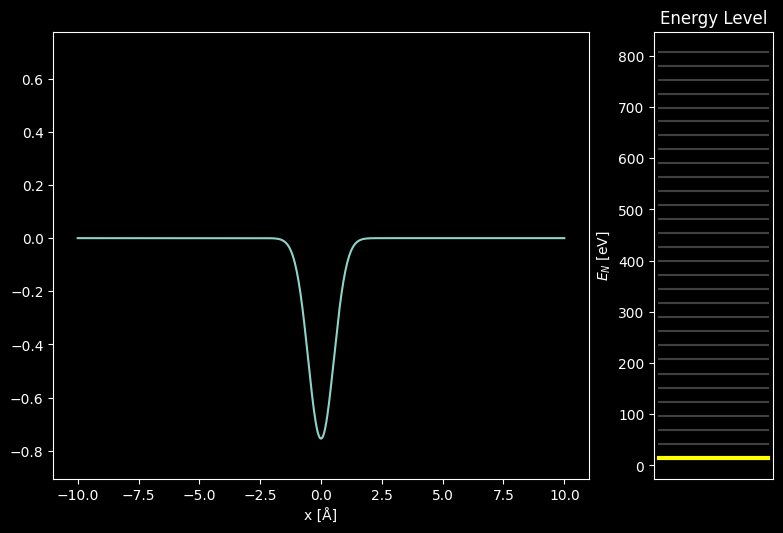

In [7]:
def harmonic_oscillator(particle):
    k = 100 * eV / Å**2
    return 0.5 * k * particle.x**2

H = Hamiltonian(particles = SingleParticle(), potential = harmonic_oscillator, 
                spatial_ndim = 1, N = 512, extent = 20*Å)

eigenstates = H.solve(max_states = 30)

print(eigenstates.energies)

visualization = init_visualization(eigenstates)
visualization.plot_eigenstate(0)

<ol start=5>
    <li>What is on the x-axis of your plots?</li>
    <li>Are your plots showing wave functions $\psi(x)$ or probability functions $\psi^*(x) \psi(x)$? How do you know?</li>
</ol>

### New potential: infinite square well

Below I define the infinite square well potential for $L = 8$ Angstroms and plot the two lowest-energy eigenstates (compare to Figure 6.3 in your textbook).

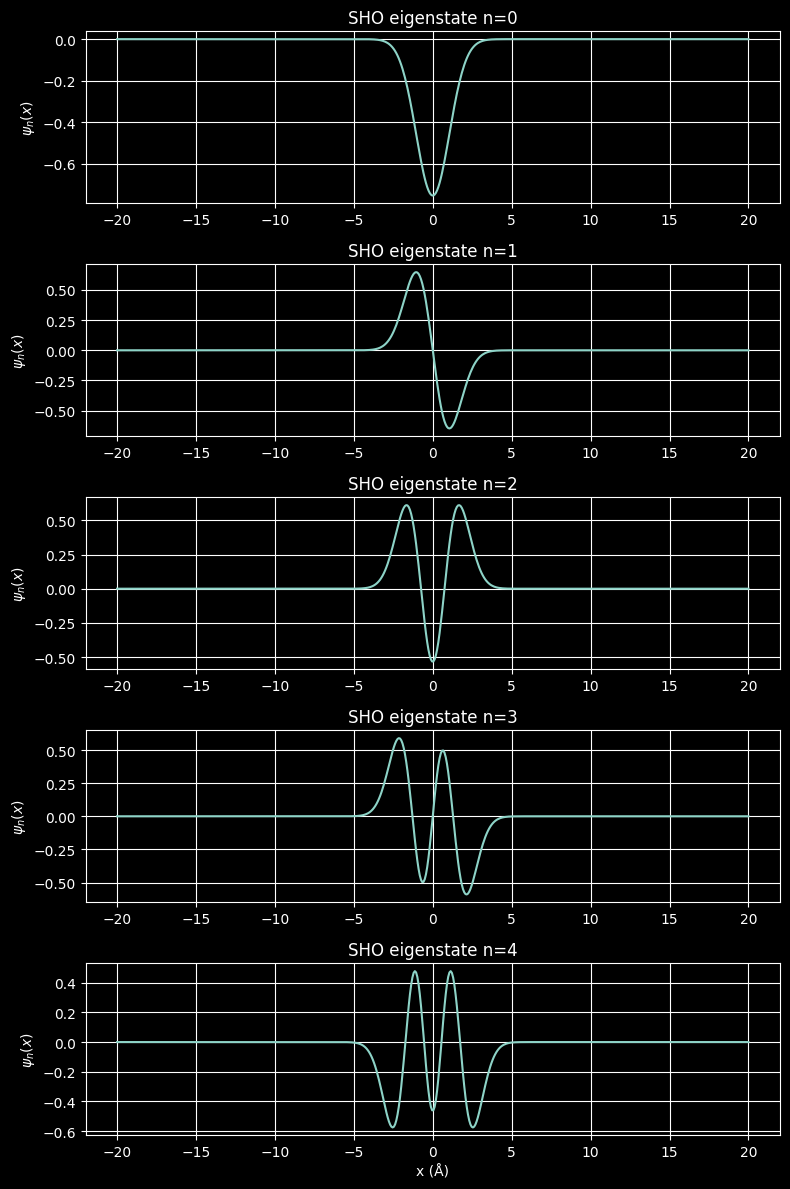

In [8]:
x = np.linspace(-H.extent, H.extent, H.N) / Å
fig, axes = plt.subplots(5, 1, figsize=(8, 12))
for n in range(5):
    axes[n].plot(x, eigenstates.array[n])
    axes[n].set_ylabel(r"$\psi_n(x)$")
    axes[n].set_title(f"SHO eigenstate n={n}")
    axes[n].grid(True)
axes[-1].set_xlabel("x (Å)")
plt.tight_layout()
plt.show()

<ol start=7>
    <li>Plot any three infinite square well eigenstates of your choice.</li>
    <li>What property do the infinite square well eigenstates have that's different than the SHO eigenstates? (Hint: think about the properties of valid wave functions we discussed in class)</li>
    <li>What is the relationship between the number of extrema (maxima plus minima) in each eigenstate plot and the quantum number of the eigenstate?</li>
</ol>

Computing...
Took 0.010169267654418945
[  0.58926935   2.35704264   5.30321556   9.4276143   14.7299955
  21.21004635  28.8673845   37.70155819  47.71204619  58.89825789
  71.2595333   84.79514311  99.50428872 115.3861023  132.43964681
 150.6639161  170.05783494 190.6202591  212.34997539 235.24570176
 259.30608737 284.52971266 310.91508944 338.46066097 367.16480207
 397.0258192  428.04195057 460.21136622 493.53216816 528.00239048]


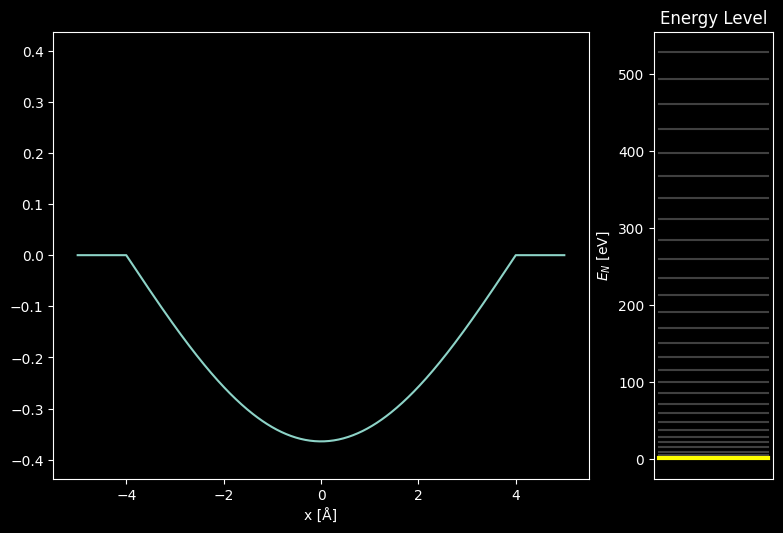

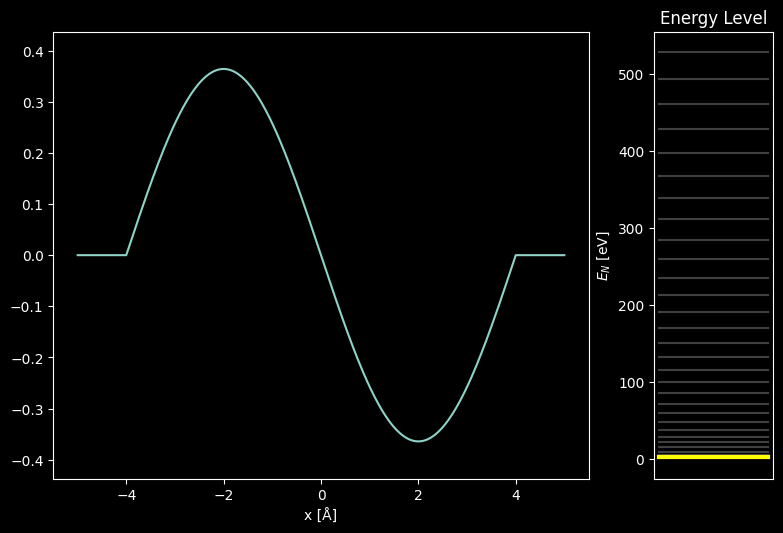

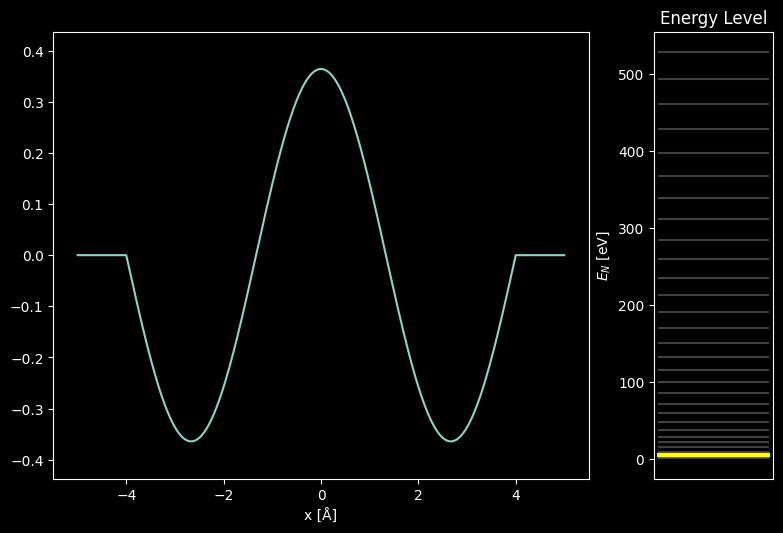

In [9]:
def infinite_square_well(particle):
    potential = np.zeros_like(particle.x)
    out_of_bounds = np.abs(particle.x) > 4*Å
    potential[out_of_bounds] = np.inf
    return potential

H_sw = Hamiltonian(particles = SingleParticle(), potential = infinite_square_well, 
                   spatial_ndim = 1, N = 512, extent = 10*Å)

eigenstates_sw = H_sw.solve(max_states = 30)

print(eigenstates_sw.energies)

visualization_sw = init_visualization(eigenstates_sw)
visualization_sw.plot_eigenstate(0)
visualization_sw.plot_eigenstate(1)
visualization_sw.plot_eigenstate(2)

### Now it's your turn to define a potential

<ol start=10>
    <li>Write a function that defines a <em>finite square-well</em> potential (textbook section 5.4). You can choose the width of the well in Angstroms and the potential at the walls in eV. Calculate the finite square-well Hamiltonian and plot any five eigenstates you choose.</li>
    <li>Based on your plots, do you think a particle can get out of the finite square-well potential no matter its quantum number $n$?</li>
</ol>

Computing...
Took 0.0029997825622558594
Finite square well energies (eV):
n=0: 0.4430 eV
n=1: 1.7605 eV
n=2: 3.9104 eV
n=3: 6.7804 eV
n=4: 9.8528 eV


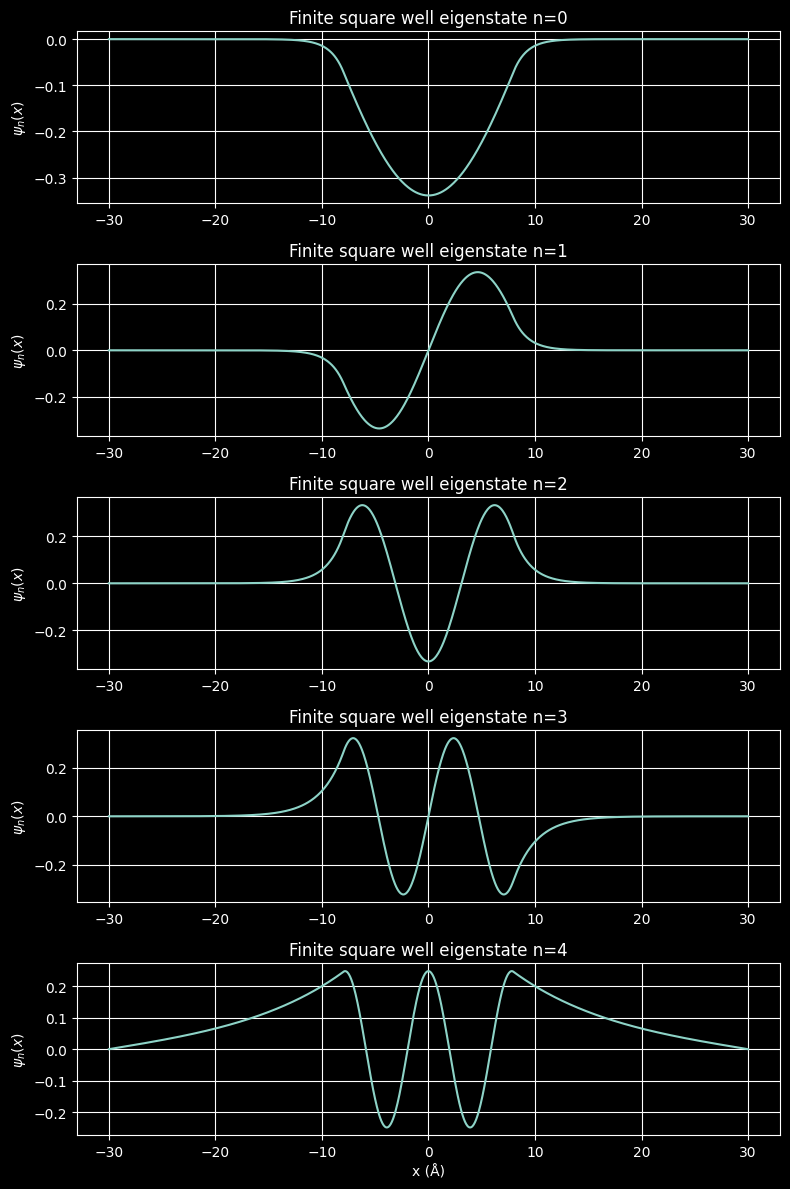

In [10]:
def finite_square_well(particle, width=8*Å, height=10*eV):
    potential = np.full_like(particle.x, height)
    inside = np.abs(particle.x) <= width / 2
    potential[inside] = 0.0
    return potential

H_fsw = Hamiltonian(particles=SingleParticle(), potential=finite_square_well,
                    spatial_ndim=1, N=1024, extent=30*Å)

E_fsw = H_fsw.solve(max_states=10)
print("Finite square well energies (eV):")
for n, energy in enumerate(E_fsw.energies[:5]):
    print(f"n={n}: {energy:.4f} eV")

x_fsw = np.linspace(-H_fsw.extent, H_fsw.extent, H_fsw.N) / Å
fig, axes = plt.subplots(5, 1, figsize=(8, 12))
for n in range(5):
    axes[n].plot(x_fsw, E_fsw.array[n])
    axes[n].set_ylabel(r"$\psi_n(x)$")
    axes[n].set_title(f"Finite square well eigenstate n={n}")
    axes[n].grid(True)
axes[-1].set_xlabel("x (Å)")
plt.tight_layout()
plt.show()

### Answers
1. A Hamiltonian is the quantum operator for total energy; it combines kinetic and potential energy and determines allowed energy levels via the Schrödinger equation.(https://en.wikipedia.org/wiki/Hamiltonian_(quantum_mechanics))
2. The function harmonic_oscillator() codes Hooke's law with the potential function of $V(x)=\tfrac{1}{2} k x^2$, which has a force of $F=-kx$.
3. The eigenstates are the stationary energy eigenfunctions $\psi_n(x)$ satisfying $H\psi_n = E_n \psi_n$. Each eigenstate is a wavefunction with a definite energy.(https://en.wikipedia.org/wiki/Eigenstate), (https://physics.stackexchange.com/questions/108012/what-is-an-eigenstate)
4. Lines 22 and 23 refer to the SHO energy eigenfunctions, where $n=0$ is the ground state and higher $n$ are excited states.
5. The x-axis is position $(x)$ in the units of angstroms (Å).
6. These plots show the wavefunction $\psi(x)$ because the curves take both positive and negative values and cross zero. 
    A probability density $\psi^*\psi$ would be nonnegative.
7. The infinite square well eigenstates are zero at the hard walls and are strictly confined inside the well, while SHO eigenstates extend outside any finite interval and decay smoothly at large values of $|x|$.
8. A valid infinite well eigenstate must vanish at the boundaries because the potential is infinite there.
    SHO eigenstates are not required to be zero at finite $x$.
9. For the infinite square well, the number of extrema in eigenstate $n$ is $n+1$ if $n$ starts at 0.
10. A finite square well has a finite barrier height, so the wave function penetrates the walls and does not vanish exactly outside the well.
11. Because of quantum tunneling, even bound states have a nonzero probability of being found outside the well, so a particle can get out of the well for all bound quantum numbers.